In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Download CSPX.L data
raw = yf.download("CSPX.L", start="2020-01-01", end="2024-12-31", progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

close  = raw["Close"].squeeze()
volume = raw["Volume"].squeeze()
returns = close.pct_change().dropna()

print(f"Data loaded: {len(close)} days")
print(f"Period: {close.index[0].date()} → {close.index[-1].date()}")

# ── Market maker parameters ──────────────────────────────────────
# A market maker quotes a bid and ask around the mid price.
# Spread = how much he earns per round trip
# Inventory limit = max number of shares he holds at any time
# He earns the spread when a trade hits his quote,
# but loses money if the price moves against his inventory.

params = {
    "spread_bps":      20,    # quoted spread in bps (10 each side)
    "inventory_limit": 1000,  # max shares held (long or short)
    "volume_fraction": 0.01,  # fraction of daily volume he participates in
    "annual_vol":      returns.std() * np.sqrt(252),
}

print(f"\nMarket maker parameters:")
print(f"  Quoted spread:    {params['spread_bps']} bps")
print(f"  Inventory limit:  {params['inventory_limit']} shares")
print(f"  Volume fraction:  {params['volume_fraction']:.0%}")
print(f"  Annual vol CSPX:  {params['annual_vol']:.1%}")

Data loaded: 1261 days
Period: 2020-01-02 → 2024-12-30

Market maker parameters:
  Quoted spread:    20 bps
  Inventory limit:  1000 shares
  Volume fraction:  1%
  Annual vol CSPX:  18.9%


In [3]:
# ── Market Making Simulation ─────────────────────────────────────
# Each day:
# 1. Market maker participates in a fraction of daily volume
# 2. He earns half the spread on each trade (bid or ask)
# 3. His inventory changes with each trade
# 4. If inventory hits the limit, he reduces position at mid (no spread)
# 5. His P&L = spread income - inventory losses from price moves

np.random.seed(42)

spread_bps      = params["spread_bps"]
inventory_limit = params["inventory_limit"]
volume_fraction = params["volume_fraction"]

# Results storage
inventory    = [0]       # shares held
pnl_spread   = [0]       # cumulative spread income
pnl_inventory= [0]       # cumulative inventory P&L
pnl_total    = [0]       # total cumulative P&L
daily_trades = []        # shares traded per day

for i in range(1, len(close)):
    price_today     = close.iloc[i]
    price_yesterday = close.iloc[i-1]
    vol_today       = volume.iloc[i]
    daily_return    = returns.iloc[i-1] if i > 1 else 0

    # Shares traded today
    shares_traded = int(vol_today * volume_fraction)
    daily_trades.append(shares_traded)

    # Spread income: earn spread/2 on each side per share traded
    half_spread = price_today * (spread_bps / 10000) / 2
    spread_income = shares_traded * half_spread

    # Inventory change: random buy/sell flow
    # Positive = more buys (MM sells, goes short)
    # Negative = more sells (MM buys, goes long)
    flow = np.random.choice([-1, 1]) * shares_traded * 0.1
    new_inventory = inventory[-1] + flow

    # Inventory limit check — flatten if exceeded
    if abs(new_inventory) > inventory_limit:
        new_inventory = np.sign(new_inventory) * inventory_limit

    # Inventory P&L: price move * inventory held
    inv_pnl = inventory[-1] * (price_today - price_yesterday)

    # Update
    inventory.append(new_inventory)
    pnl_spread.append(pnl_spread[-1] + spread_income)
    pnl_inventory.append(pnl_inventory[-1] + inv_pnl)
    pnl_total.append(pnl_spread[-1] + pnl_inventory[-1])

# Build results DataFrame
results = pd.DataFrame({
    "price":         close.values,
    "inventory":     inventory,
    "pnl_spread":    pnl_spread,
    "pnl_inventory": pnl_inventory,
    "pnl_total":     pnl_total,
}, index=close.index)

print("Simulation complete.")
print(f"\nFinal P&L summary:")
print(f"  Spread income:    ${results['pnl_spread'].iloc[-1]:>12,.0f}")
print(f"  Inventory P&L:    ${results['pnl_inventory'].iloc[-1]:>12,.0f}")
print(f"  Total P&L:        ${results['pnl_total'].iloc[-1]:>12,.0f}")
print(f"\n  Max inventory:    {max(abs(i) for i in inventory):>8,.0f} shares")
print(f"  Avg daily trades: {np.mean(daily_trades):>8,.0f} shares")

Simulation complete.

Final P&L summary:
  Spread income:    $     631,815
  Inventory P&L:    $     -82,556
  Total P&L:        $     549,259

  Max inventory:       1,000 shares
  Avg daily trades:    1,167 shares


In [4]:
# P&L analysis by market regime
regimes = {
    "Covid crash":    ("2020-02-20", "2020-04-30"),
    "Bull 2021":      ("2021-01-01", "2021-12-31"),
    "Fed hike 2022":  ("2022-01-01", "2022-12-31"),
    "Normal 2023":    ("2023-01-01", "2023-12-31"),
    "Bull 2024":      ("2024-01-01", "2024-12-31"),
}

print(f"{'Period':<20} {'Spread P&L':>12} {'Inv P&L':>12} {'Total P&L':>12} {'Sharpe':>8}")
print("=" * 68)

for period, (start, end) in regimes.items():
    r = results.loc[start:end]
    
    # Daily P&L
    daily_spread = r["pnl_spread"].diff().dropna()
    daily_inv    = r["pnl_inventory"].diff().dropna()
    daily_total  = r["pnl_total"].diff().dropna()
    
    total_spread = daily_spread.sum()
    total_inv    = daily_inv.sum()
    total        = daily_total.sum()
    sharpe       = daily_total.mean() / daily_total.std() * np.sqrt(252) \
                   if daily_total.std() > 0 else 0
    
    print(f"{period:<20} ${total_spread:>10,.0f} ${total_inv:>10,.0f} "
          f"${total:>10,.0f} {sharpe:>8.2f}")

Period                 Spread P&L      Inv P&L    Total P&L   Sharpe
Covid crash          $    38,905 $   -66,629 $   -27,724    -1.57
Bull 2021            $    99,487 $    78,862 $   178,348     4.03
Fed hike 2022        $   119,120 $   -50,610 $    68,510     0.88
Normal 2023          $   120,529 $    18,278 $   138,807     3.64
Bull 2024            $   171,655 $   -69,559 $   102,096     2.48


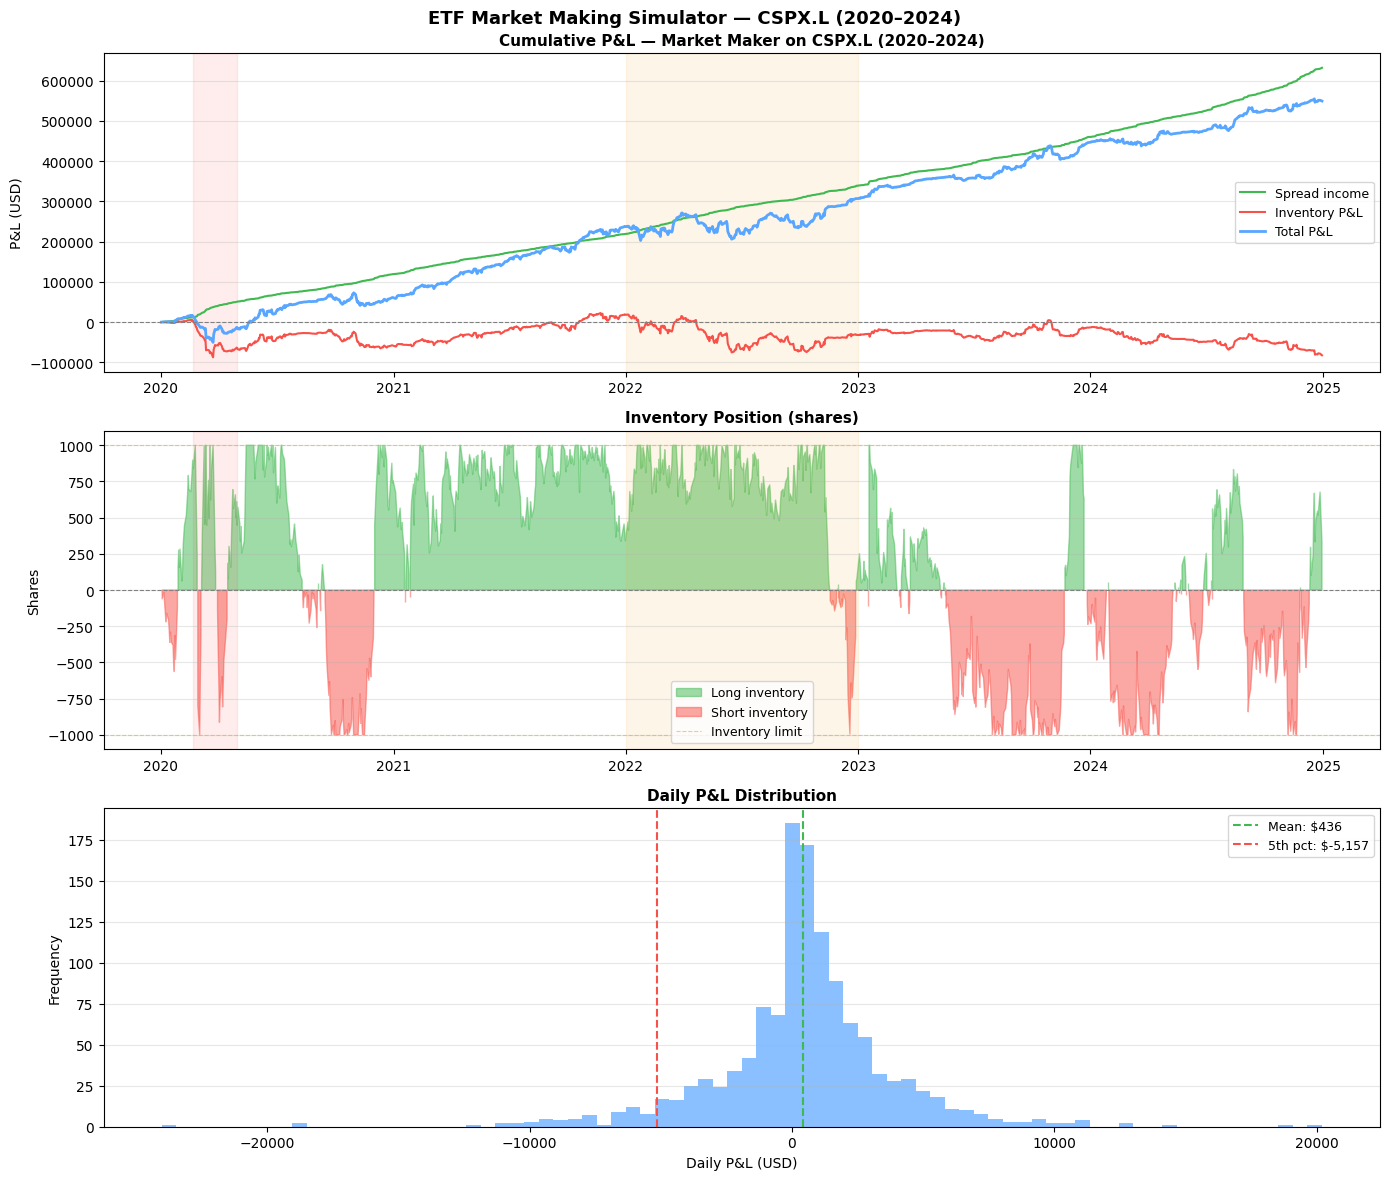

Chart saved.


In [5]:
# Market making simulation charts
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

covid_start = mdates.date2num(pd.Timestamp("2020-02-20").to_pydatetime())
covid_end   = mdates.date2num(pd.Timestamp("2020-04-30").to_pydatetime())
fed_start   = mdates.date2num(pd.Timestamp("2022-01-01").to_pydatetime())
fed_end     = mdates.date2num(pd.Timestamp("2022-12-31").to_pydatetime())

# ── Chart 1: Cumulative P&L ──
ax1 = axes[0]
ax1.plot(results.index, results["pnl_spread"],
         color="#3fb950", linewidth=1.5, label="Spread income")
ax1.plot(results.index, results["pnl_inventory"],
         color="#f85149", linewidth=1.5, label="Inventory P&L")
ax1.plot(results.index, results["pnl_total"],
         color="#58a6ff", linewidth=2, label="Total P&L")
ax1.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax1.axvspan(covid_start, covid_end, color="#f85149", alpha=0.1)
ax1.axvspan(fed_start,   fed_end,   color="#f5a623", alpha=0.1)
ax1.set_title("Cumulative P&L — Market Maker on CSPX.L (2020–2024)",
              fontweight="bold", fontsize=11)
ax1.set_ylabel("P&L (USD)")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# ── Chart 2: Inventory ──
ax2 = axes[1]
ax2.fill_between(results.index, results["inventory"],
                  where=results["inventory"] >= 0,
                  color="#3fb950", alpha=0.5, label="Long inventory")
ax2.fill_between(results.index, results["inventory"],
                  where=results["inventory"] < 0,
                  color="#f85149", alpha=0.5, label="Short inventory")
ax2.axhline(0,              color="gray",    linewidth=0.8, linestyle="--")
ax2.axhline(inventory_limit,  color="#f5a623", linewidth=0.8,
            linestyle="--", alpha=0.6, label="Inventory limit")
ax2.axhline(-inventory_limit, color="#f5a623", linewidth=0.8,
            linestyle="--", alpha=0.6)
ax2.axvspan(covid_start, covid_end, color="#f85149", alpha=0.1)
ax2.axvspan(fed_start,   fed_end,   color="#f5a623", alpha=0.1)
ax2.set_title("Inventory Position (shares)",
              fontweight="bold", fontsize=11)
ax2.set_ylabel("Shares")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

# ── Chart 3: Daily P&L distribution ──
ax3 = axes[2]
daily_pnl = results["pnl_total"].diff().dropna()

ax3.hist(daily_pnl, bins=80, color="#58a6ff", alpha=0.7, edgecolor="none")
ax3.axvline(daily_pnl.mean(),   color="#3fb950", linewidth=1.5,
            linestyle="--", label=f"Mean: ${daily_pnl.mean():,.0f}")
ax3.axvline(daily_pnl.quantile(0.05), color="#f85149", linewidth=1.5,
            linestyle="--", label=f"5th pct: ${daily_pnl.quantile(0.05):,.0f}")
ax3.set_title("Daily P&L Distribution",
              fontweight="bold", fontsize=11)
ax3.set_xlabel("Daily P&L (USD)")
ax3.set_ylabel("Frequency")
ax3.legend(fontsize=9)
ax3.grid(axis="y", alpha=0.3)

fig.suptitle("ETF Market Making Simulator — CSPX.L (2020–2024)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/market_making.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## Model Description

A simplified market making simulation on CSPX.L (iShares S&P 500 UCITS ETF).

### How it works
- The market maker quotes a **bid and ask** around the mid price
- He earns **half the spread** on each side of every trade
- His **inventory** changes with random order flow
- If inventory hits the limit (1,000 shares), he stops adding exposure
- His total P&L = **spread income** (always positive) + **inventory P&L**
  (depends on price moves)

### Parameters
- Quoted spread: **20 bps**
- Inventory limit: **±1,000 shares**
- Volume participation: **1% of daily volume**

## Key Findings

### Overall (2020–2024)
- Total spread income: **$631,815** — steady, predictable revenue stream
- Inventory P&L: **-$82,556** — small losses from directional exposure
- Total P&L: **$549,259** — consistently profitable over the full period

### By market regime

| Period | Spread P&L | Inv P&L | Total P&L | Sharpe |
|---|---|---|---|---|
| Covid crash (2020) | $38,905 | -$66,629 | -$27,724 | -1.57 |
| Bull market (2021) | $99,487 | +$78,862 | $178,348 | 4.03 |
| Fed hike cycle (2022) | $119,120 | -$50,610 | $68,510 | 0.88 |
| Normal (2023) | $120,529 | +$18,278 | $138,807 | 3.64 |
| Bull (2024) | $171,655 | -$69,559 | $102,096 | 2.48 |

### Core insight
Market making is **profitable on average but dangerous during crises**.
During Covid, spread income ($38K) was insufficient to cover inventory
losses (-$66K) as the market fell 30% in weeks.

The key risk is **adverse selection** — when prices move directionally,
the market maker accumulates inventory on the wrong side.
Professional market makers manage this via:
- Dynamic spread widening during volatile periods
- Delta hedging via futures (ES1 for S&P 500 ETFs)
- Hard inventory limits and real-time risk monitoring

### Limitations
This is a simplified model. A real ETF market maker would:
- Use intraday tick data (not daily closes)
- Hedge inventory continuously via S&P 500 futures
- Adjust spreads dynamically based on volatility (VIX)
- Account for creation/redemption mechanism with the ETF issuer